In [1]:
#importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleaanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

#filter for data analyst data
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

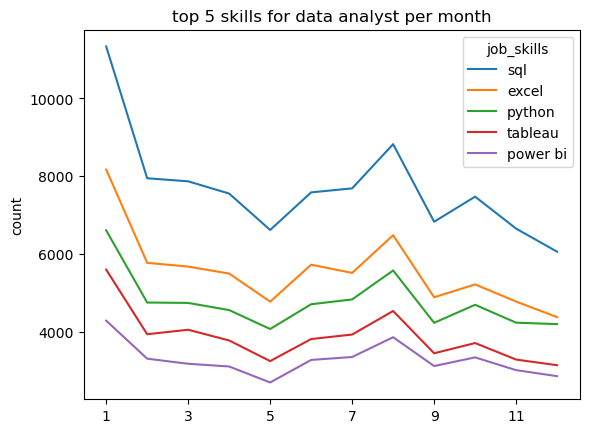

In [2]:
df_DA['job_posted_month_num'] = df_DA['job_posted_date'].dt.month

df_DA_explode = df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_num', columns='job_skills', aggfunc='size', fill_value= 0)
df_DA_pivot.loc['total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('total')


df_DA_pivot.iloc[:, :5].plot(kind='line')
plt.title('top 5 skills for data analyst per month')
plt.ylabel('count')
plt.xlabel("")
plt.show()

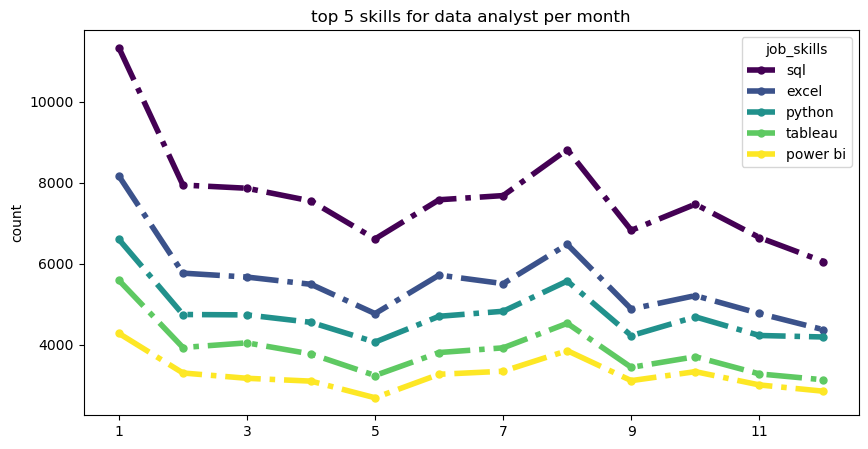

In [3]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle='-.', #options = '-' '--' '-.' ':'
    colormap='viridis',
    marker='o',
    markersize=5,
    figsize=(10, 5)
  )

plt.title('top 5 skills for data analyst per month')
plt.ylabel('count')
plt.xlabel("")
plt.show()

In [4]:
df_exploded = df_DA.explode('job_skills')


skill_status = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

skill_count = 20
skill_status = skill_status.sort_values(by='skill_count', ascending=False).head(skill_count)
skill_status

,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


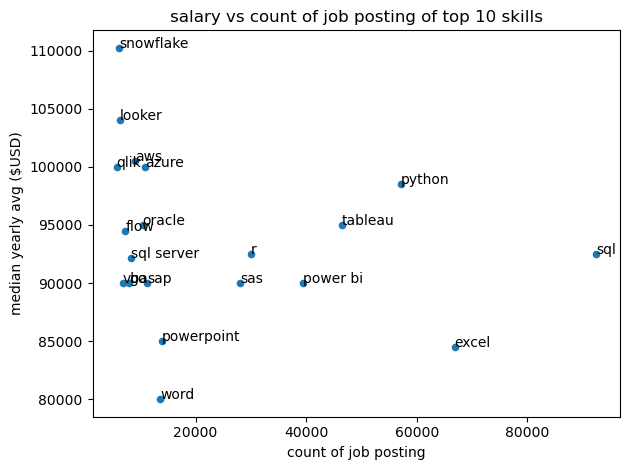

In [5]:
skill_status.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('count of job posting')
plt.ylabel('median yearly avg ($USD)')
plt.title('salary vs count of job posting of top 10 skills')
plt.tight_layout()

for i, txt in enumerate(skill_status.index):
    plt.text(skill_status['skill_count'].iloc[i], skill_status['median_salary'].iloc[i], txt)

plt.show()

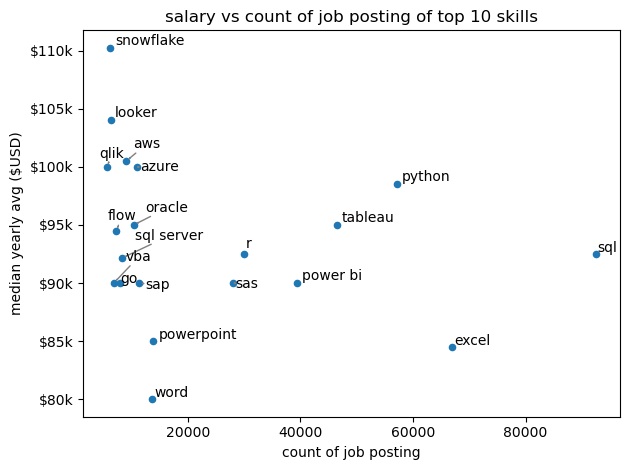

In [22]:
from adjustText import adjust_text
skill_status.plot(kind='scatter', x='skill_count', y='median_salary')

texts = []
for i, txt in enumerate(skill_status.index):
    texts.append(plt.text(skill_status['skill_count'].iloc[i], skill_status['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))
plt.xlabel('count of job posting')
plt.ylabel('median yearly avg ($USD)')
plt.title('salary vs count of job posting of top 10 skills')
plt.tight_layout()

plt.show()